<div style="
background-color:#EAEAEA;
padding:15px;
border-left:5px solid #6C757D;
border-radius:6px;">

# Master's Thesis in Advanced Physics
---

This notebook is part of the **Master's Thesis (MSc Dissertation)**: **Fast Simulation of Neutrino Oscillations in Matter**.

**Author**
Juan Ramon Diaz Santos <diazjuan@alumni.uv.es>

**Supervisors**
Roberto Ruiz de Austri Bazan <rruiz@ific.uv.es>
Michele Lucente <michele.lucente@unibo.it>

**Date**
June 2026
</div>

# Validation NuSQuIDS 2: Solar Neutrino Propagation
---

Validates `tpeanuts` solar MSW propagation against `nuSQuIDS` as an external
reference. The comparison operates at two levels:

1. **Single-point propagation** — for a fixed production radius $r_0$, compare
   the survival probability $P_{ee}(E, r_0)$ from both backends.
2. **Source-averaged probability** — compare `psolar` against a manual
   quadrature over NuSQuIDS single-point results, weighted by the B16 AGSS09
   production fractions.

An antineutrino section checks the matter-effect sign convention.

## Table of Contents

| § | Title |
|---|-------|
| [0](#0.-Theory-Background) | **Theory Background** — MSW matter potential, adiabatic approximation, Landau-Zener correction, B16 solar model, NuSQuIDS SunASnu body |
| [1](#1.-Libraries) | **Libraries** |
| [2](#2.-Paths-and-Configuration) | **Paths and Configuration** — notebook paths, physical parameters |
| [3](#3.-Matter-Mixing-Angle) | **Matter Mixing Angle** — $\theta_{12}^M$ vs density |
| [4](#4.-Single-Point-Propagation) | **Single-Point Propagation** — $P_{ee}$ from fixed $r_0$ |
| [5](#5.-Source-Averaged-P_ee) | **Source-Averaged $P_{ee}$** — $^8$B spectrum |
| [6](#6.-pp-Source) | **pp Source** — low-energy regime, LZ correction |
| [7](#7.-Antineutrino-Propagation) | **Antineutrino** $\bar{P}_{ee}$ |
| [8](#8.-Mass-Weights-Normalization) | **Mass Weights Normalization** |
| [9](#9.-Export-Tables) | **Export Tables** |
| [∑](#∑.-Summary) | **Summary** |

## 0. Theory Background

Solar neutrino propagation combines coherent matter effects in the solar
interior (MSW mechanism) with decoherence over the Sun–Earth baseline.
The subsections below cover the matter potential, the adiabatic and
non-adiabatic (Landau-Zener) approximations, the B16 AGSS09 solar model, and
the NuSQuIDS SunASnu body used as the external reference.

### 0.1 MSW Matter Effect

In matter with electron number density $n_e$, the neutrino Hamiltonian gains a
charged-current forward-scattering potential

$$
A(x) = \sqrt{2}\, G_F n_e(x) ,
$$

which modifies the effective mixing in the electron-neutrino sector. The full
Hamiltonian in the flavour basis becomes

$$
H_m = \frac{1}{2E} U M^2 U^\dagger + \operatorname{diag}(A, 0, 0) ,
$$

where $M^2 = \operatorname{diag}(0, \Delta m^2_{21}, \Delta m^2_{31})$. The
resonance condition $\Delta m^2_{21}\cos 2\theta_{12}/2E = A$ signals the
maximum mixing in matter [[Wolfenstein 1978](https://doi.org/10.1103/PhysRevD.17.2369);
[Mikheyev & Smirnov 1985](https://doi.org/10.1007/BF02508049)].


### 0.2 Adiabatic Approximation

When the density varies slowly compared to the oscillation length, the
neutrino remains in the same matter eigenstate throughout propagation. The
adiabatic survival probability for $\nu_e$ produced at radius $r_0$ with
density $n_e(r_0)$ is

$$
P_{ee}^{\rm ad}(E, r_0) = \sum_i \left|U_{ei}^M(r_0)\right|^2 |U_{ei}|^2 ,
$$

where $U^M$ is the PMNS matrix in matter at density $n_e(r_0)$ and $U$ is the
vacuum PMNS matrix (evaluated at the solar surface, $n_e \approx 0$). In
`tpeanuts` this is computed by `Tei(oscillation, E, ne)`, which returns
$\{|U_{ei}^M|^2\}_i$ [[Haxton 1986](https://doi.org/10.1103/PhysRevLett.57.1271)].


### 0.3 Landau-Zener Non-Adiabatic Correction

Near the resonance the adiabaticity parameter

$$
\gamma = \frac{(\Delta m^2_{21} \sin 2\theta_{12})^2}
               {2E\,|{\rm d}A/{\rm d}x|_{\rm res}}
$$

can be small. The Landau-Zener crossing probability
$P_{\rm LZ} = e^{-\pi\gamma/2}$ corrects the level-crossing amplitude.
This correction is most relevant for $pp$ neutrinos ($E \lesssim 0.5$ MeV)
where the resonance lies inside the Sun. `tpeanuts` includes it via
`psolar(..., use_lz=True)` [[Parke 1986](https://doi.org/10.1103/PhysRevLett.57.1275)].


### 0.4 Solar Model B16 AGSS09

`tpeanuts` uses the Vinyoles et al. B16 standard solar model (AGSS09
composition). The electron density $n_e(r/R_\odot)$ is tabulated on a
2000-point radial grid. For each neutrino source the production fraction
$f_s(r)$ gives the probability of being produced at radius $r$, so the
source-averaged probability is

$$
\langle P_{\alpha\beta}\rangle_s = \int_0^1 f_s(r)\, P_{\alpha\beta}(E, r)\, {\rm d}r .
$$

`psolar(oscillation, E, profile, source)` implements this integral
analytically with the adiabatic + LZ approximation
[[Vinyoles et al. 2017](https://doi.org/10.3847/1538-4357/835/2/202)].


### 0.5 NuSQuIDS SunASnu Body

`nuSQuIDS` provides the `SunASnu` body, which embeds a tabulated solar electron-density profile and supports solar trajectories with an impact parameter. In this notebook the comparison uses **radial outward tracks** with zero impact parameter. For a neutrino produced at radius $r_0$ in solar-radius units, the correct radial track is built from

```python
R_sun = nsq.SunASnu.Track(0.0).GetFinalX()
track = nsq.SunASnu.Track(r0 * R_sun, 0.0)
```

The previous convention `xini = (1 + r0) R_sun` corresponds to a different geometric point and should not be used for a production radius measured from the solar centre.

Solar neutrino propagation to Earth is not observed coherently. Therefore the nuSQuIDS output is converted to an incoherent solar observable by reading the mass-basis contents at the solar surface with `EvalMass(i)` and projecting them to flavour with the vacuum matrix elements $|U_{\alpha i}|^2$:

$$
P_{e\alpha}^{\rm decoh}(E,r_0)=\sum_i w_i^{\rm nsq}(E,r_0)|U_{\alpha i}|^2.
$$

When the installed bindings do not expose `EvalMass`, the notebook tries the averaged `EvalFlavor` overload. A coherent `EvalFlavor(i)` value is not a valid solar reference for the TPeanuts adiabatic/decohered probability.


### References

- Wolfenstein, L. (1978). *Neutrino oscillations in matter*. Phys. Rev. D **17**, 2369. [doi:10.1103/PhysRevD.17.2369](https://doi.org/10.1103/PhysRevD.17.2369)
- Mikheyev, S. P., & Smirnov, A. Yu. (1985). *Resonance amplification of oscillations in matter and spectroscopy of solar neutrinos*. Sov. J. Nucl. Phys. **42**, 913.
- Haxton, W. C. (1986). *Adiabatic conversion of solar neutrinos*. Phys. Rev. Lett. **57**, 1271. [doi:10.1103/PhysRevLett.57.1271](https://doi.org/10.1103/PhysRevLett.57.1271)
- Parke, S. (1986). *Nonadiabatic level crossing in resonant neutrino oscillations*. Phys. Rev. Lett. **57**, 1275. [doi:10.1103/PhysRevLett.57.1275](https://doi.org/10.1103/PhysRevLett.57.1275)
- Vinyoles, N. et al. (2017). *A new generation of standard solar models*. Astrophys. J. **835**, 202. [doi:10.3847/1538-4357/835/2/202](https://doi.org/10.3847/1538-4357/835/2/202)
- Esteban, I. et al. (NuFIT 5.2, 2022). *NuFIT 5.2 global analysis of three-flavour neutrino oscillations*. JHEP **09**, 178.
- Argüelles, C. A., Salvado, J., & Weaver, C. N. (2022). *nuSQuIDS: A toolbox for neutrino propagation*. Comput. Phys. Commun. **277**, 108346. [arXiv:2112.09122](https://arxiv.org/abs/2112.09122)

## 1. Libraries


In [1]:
from __future__ import annotations

%matplotlib inline
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from tpeanuts.notebooks.notebookConfig import load_notebook_config
from tpeanuts.notebooks.notebooks_helper import (
    FLAVOUR_NAMES, FLAVOUR_LABELS, FLAVOUR_COLORS, FLAVOUR_INDEX,
    to_numpy, abs_rel_delta, add_tolerance_lines, save_and_show,
    try_import_nusquids, nusquids_is_available,
    compare_probability_grids, nusquids_precision_summary,
    plot_comparison_curves, status_from_rel,
)
from tpeanuts.external.nusquids.core import (
    NuSQuIDSConfig, init_solver,
)
from tpeanuts.util.context import RuntimeContext
from tpeanuts.core.common.oscillation import OscillationParameters
from tpeanuts.medium.solar.profile import SolarProfile
from tpeanuts.medium.solar.probability import psolar, solar_probability_mass, Tei, th12_M


## 2. Paths and Configuration

### 2.1 Paths

`load_notebook_config()` resolves the repository root, applies the shared matplotlib/torch/numpy style, and creates the output directory. All figures and CSV files from this notebook are saved under `validation/nusquids/`.

In [2]:
config     = load_notebook_config()
ctx        = RuntimeContext.resolve(config.device, config.dtype)
OUTPUT_DIR = config.output_dir("validation", "nusquids")
SHOW       = config.show_plots

print(f"Device : {ctx.device}   dtype : {ctx.dtype}")
print(f"Output : {OUTPUT_DIR}")
print(f"nuSQuIDS available: {nusquids_is_available()}")


Device : cpu   dtype : torch.float64
Output : /mnt/v/output/validation/nusquids
nuSQuIDS available: True


### 2.2 Configuration

Physical parameters shared by both backends. Both use NuFIT 5.2 Normal Ordering and the B16 AGSS09 solar profile.

| Parameter | Value | Description |
|-----------|-------|-------------|
| Preset | `_SM_NUFIT52_NO` | NuFIT 5.2 NO |
| Solar profile | B16 AGSS09 (default) | 2000-point radial grid |
| Energy range | [0.1, 20] MeV, 80 points | Solar neutrino window |
| Production radii (single-point) | [0, 0.05, 0.1, 0.2, 0.3, 0.5] R☉ | Fixed-point comparison |
| Sources | `8B`, `pp`, `pep` | Three main sources |
| `rel_error` (nuSQuIDS) | 10⁻⁷ | SunASnu integration tolerance |

In [3]:
oscillation    = OscillationParameters.from_preset("_SM_NUFIT52_NO", antinu=False, context=ctx)
solar_profile  = SolarProfile.default(context=ctx)

E_MeV_SOLAR    = torch.linspace(0.2, 20.0, 10, dtype=ctx.dtype, device=ctx.device)
PROD_RADII     = [0.0, 0.05, 0.1, 0.2, 0.3, 0.5]   # r / R_sun
SOURCES        = ["8B", "pp", "pep"]
NSQ_REL_ERROR  = 1.0e-7
NSQ_ABS_ERROR  = 1.0e-10

# Vacuum PMNS weights |U_ei|^2 for the adiabatic formula
ne_zero  = torch.zeros(1, dtype=ctx.dtype)
U_ei_sq  = to_numpy(Tei(oscillation, torch.tensor(10.0, dtype=ctx.dtype), ne_zero))[0]
print("Vacuum |U_ei|^2 =", U_ei_sq.round(4).tolist())
print("sum =", U_ei_sq.sum().round(8))


/home/juan/hep/opt/corsika8-venv/lib/python3.13/site-packages/tpeanuts/medium/solar/io.py:113: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  return torch.as_tensor(values, device=default_device(device), dtype=dtype)


Vacuum |U_ei|^2 = [0.6813, 0.2964, 0.0223]
sum = 1.0


### 2.3 Helpers

The NuSQuIDS wrapper uses `SunASnu` for single-point radial propagation from production radius $r_0$ to the solar surface. The returned NuSQuIDS reference is made incoherent by projecting the final mass-basis weights onto vacuum flavour probabilities.

The TPeanuts side keeps its configured B16 AGSS09 solar density profile. Therefore the comparison validates the observable convention and track geometry, while any residual offset can still include the known density-model difference between B16 AGSS09 and the internal `SunASnu` solar model.


In [13]:
nsq_mod   = try_import_nusquids()
_nsq_u    = nsq_mod.Const() if nsq_mod else None

_NSQ_CFG = NuSQuIDSConfig(
    theta12=float(oscillation.pmns.params.theta12),
    theta13=float(oscillation.pmns.params.theta13),
    theta23=float(oscillation.pmns.params.theta23),
    delta_cp=float(oscillation.pmns.params.delta),
    DeltamSq21=float(oscillation.DeltamSq21),
    DeltamSq3l=float(oscillation.DeltamSq3l),
    rel_error=NSQ_REL_ERROR,
    abs_error=NSQ_ABS_ERROR,
    h_max_km=None,
)

# SunASnu body shared across calls. For SunASnu.Track(0.0), GetFinalX() is
# the solar radius in nuSQuIDS natural units for a radial trajectory.
_nsq_sun    = nsq_mod.SunASnu() if nsq_mod else None
_R_SUN_NU   = nsq_mod.SunASnu.Track(0.0).GetFinalX() if nsq_mod else None


def _vacuum_flavour_projector(*, antinu=False):
    """Return |U_{alpha i}|^2, shaped (flavour, mass)."""
    osc = OscillationParameters.from_preset("_SM_NUFIT52_NO", antinu=antinu, context=ctx)
    #U = to_numpy(osc.pmns.pmns_matrix(antinu=osc.antinu))
    
    U_t = osc.pmns.pmns_matrix(antinu=osc.antinu)

    if isinstance(U_t, torch.Tensor):
        U = U_t.detach().resolve_conj().cpu().numpy()
    else:
        U = np.asarray(U_t)
    return np.abs(U) ** 2


def _make_solar_track(r0, *, impact=0.0):
    """Build a radial SunASnu track for production radius r0 in R_sun units."""
    if nsq_mod is None:
        return None
    xini = float(r0) * _R_SUN_NU
    b_impact = float(impact) * _R_SUN_NU
    return nsq_mod.SunASnu.Track(xini, b_impact)


def _eval_nusquids_mass_weights(nu):
    """Read incoherent mass weights from an evolved nuSQuIDS single-energy solver."""
    eval_mass = getattr(nu, "EvalMass", None)
    if eval_mass is None:
        return None
    weights = np.array([float(eval_mass(i)) for i in range(3)], dtype=float)
    norm = weights.sum()
    if np.isfinite(norm) and norm > 0.0:
        weights = weights / norm
    return weights


def _eval_nusquids_flavour_averaged(nu):
    """Fallback for bindings without EvalMass: average H0-induced oscillations."""
    values = []
    for flv in range(3):
        averaged = [False, False, False]
        try:
            values.append(float(nu.EvalFlavor(flv, 0.0, averaged)))
        except TypeError:
            return None
    return np.array(values, dtype=float)


def nusquids_solar_point(*, E_MeV, r0, antinu=False, return_mass_weights=False):
    """Decohered P(nu_e -> nu_beta) from r0 to the solar surface via nuSQuIDS."""
    if nsq_mod is None:
        return np.full(3, float("nan"))
    nu = init_solver(antinu=antinu, config=_NSQ_CFG)
    nu.Set_Body(_nsq_sun)
    nu.Set_Track(_make_solar_track(r0))
    nu.Set_E(float(E_MeV) * 1e-3 * _nsq_u.GeV)
    ini = np.zeros(3)
    ini[0] = 1.0
    nu.Set_initial_state(ini, nsq_mod.Basis.flavor)
    nu.EvolveState()

    mass_weights = _eval_nusquids_mass_weights(nu)
    if mass_weights is not None:
        if return_mass_weights:
            return mass_weights
        return _vacuum_flavour_projector(antinu=antinu) @ mass_weights

    averaged_flavour = _eval_nusquids_flavour_averaged(nu)
    if averaged_flavour is not None:
        if return_mass_weights:
            return np.full(3, float("nan"))
        return averaged_flavour

    raise RuntimeError(
        "This nuSQuIDS binding exposes neither EvalMass nor averaged EvalFlavor; "
        "coherent EvalFlavor is not a valid solar-decohered reference."
    )



print("Solar helpers ready. NuSQuIDS SunASnu:", nsq_mod is not None)
print("R_sun_nusquids available:", _R_SUN_NU is not None)


def tpeanuts_solar_point(*, E_MeV_t, r0, antinu=False):
    """Adiabatic/decohered P_ealpha from r0 using the B16 AGSS09 solar density."""
    osc = OscillationParameters.from_preset("_SM_NUFIT52_NO", antinu=antinu, context=ctx)
    ne_r0 = solar_profile.electron_density(
        torch.tensor(r0, dtype=ctx.dtype, device=ctx.device)
    )
    T = to_numpy(Tei(osc, E_MeV_t, ne_r0.unsqueeze(0))).squeeze(0)
    U2 = _vacuum_flavour_projector(antinu=antinu)

   
    return U2 @ T


Solar helpers ready. NuSQuIDS SunASnu: True
R_sun_nusquids available: True


## 3. Matter Mixing Angle

The effective mixing angle in matter $\theta_{12}^M$ as a function of electron
density $n_e$ at fixed energy $E = 10$ MeV.

**Expected results:** $\theta_{12}^M \to \theta_{12}$ (vacuum) as $n_e \to 0$
and $\theta_{12}^M \to \pi/2$ at the MSW resonance density
$n_e^{\rm res} = \Delta m^2_{21}\cos 2\theta_{12} / (2\sqrt{2} G_F E)$.


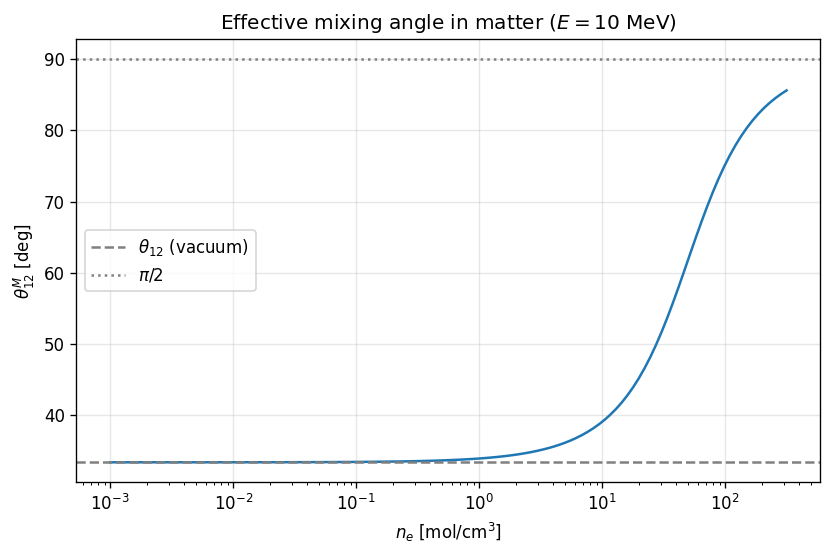

/mnt/v/output/validation/nusquids/vn2_fig31_th12M.png


In [5]:
ne_grid   = torch.logspace(-3, 2.5, 120, dtype=ctx.dtype)
E_test_t  = torch.tensor(10.0, dtype=ctx.dtype)
th12_arr  = to_numpy(th12_M(oscillation, E_test_t, ne_grid))

# Resonance density for 10 MeV
Dm21 = float(oscillation.DeltamSq21)
th12 = float(oscillation.pmns.params.theta12)
G_F  = 1.1664e-5  # GeV^-2
n_res_mev = Dm21 * math.cos(2*th12) / (2.0 * math.sqrt(2) * G_F * 1e-3 * 10.0 * 6.022e23)
# convert: eV^2 / (GeV^-2 * MeV) → mol/cm^3
n_res = n_res_mev * 1e-3 / (6.022e23 * 1e-6)  # rough conversion, display only

fig, ax = plt.subplots(figsize=(8, 4.8))
ax.semilogx(to_numpy(ne_grid), np.degrees(th12_arr), color="C0")
ax.axhline(math.degrees(th12), color="gray", ls="--", label=r"$\theta_{12}$ (vacuum)")
ax.axhline(90.0, color="gray", ls=":", label=r"$\pi/2$")
ax.set_xlabel(r"$n_e$ [mol/cm$^3$]")
ax.set_ylabel(r"$\theta_{12}^M$ [deg]")
ax.set_title(r"Effective mixing angle in matter ($E = 10$ MeV)")
ax.legend()
save_and_show("vn2_fig31_th12M.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW)


## 4. Single-Point Propagation

$P_{ee}(E)$ for $\nu_e$ produced at fixed radii $r_0 \in \{0, 0.1, 0.3\}$ $R_\odot$, propagated to the solar surface and then interpreted as an incoherent solar probability.

NuSQuIDS uses the `SunASnu` body and a corrected radial track, `Track(r0 * R_sun, 0)`. Its coherent final state is converted to a decohered solar observable by reading mass-basis weights with `EvalMass(i)` and projecting with vacuum $|U_{ei}|^2$. TPeanuts uses the same incoherent adiabatic convention while keeping the configured B16 AGSS09 solar density profile.

**Expected results:** Both backends should now compare the same physical observable. Residual differences should come from the density-profile mismatch, numerical integration, and the adiabatic approximation rather than from coherent phase interference or an incorrect solar track.


1 RADII:  0.3
..........Completed
2 RADII:  0.4
..........Completed
3 RADII:  0.6
..........Completed


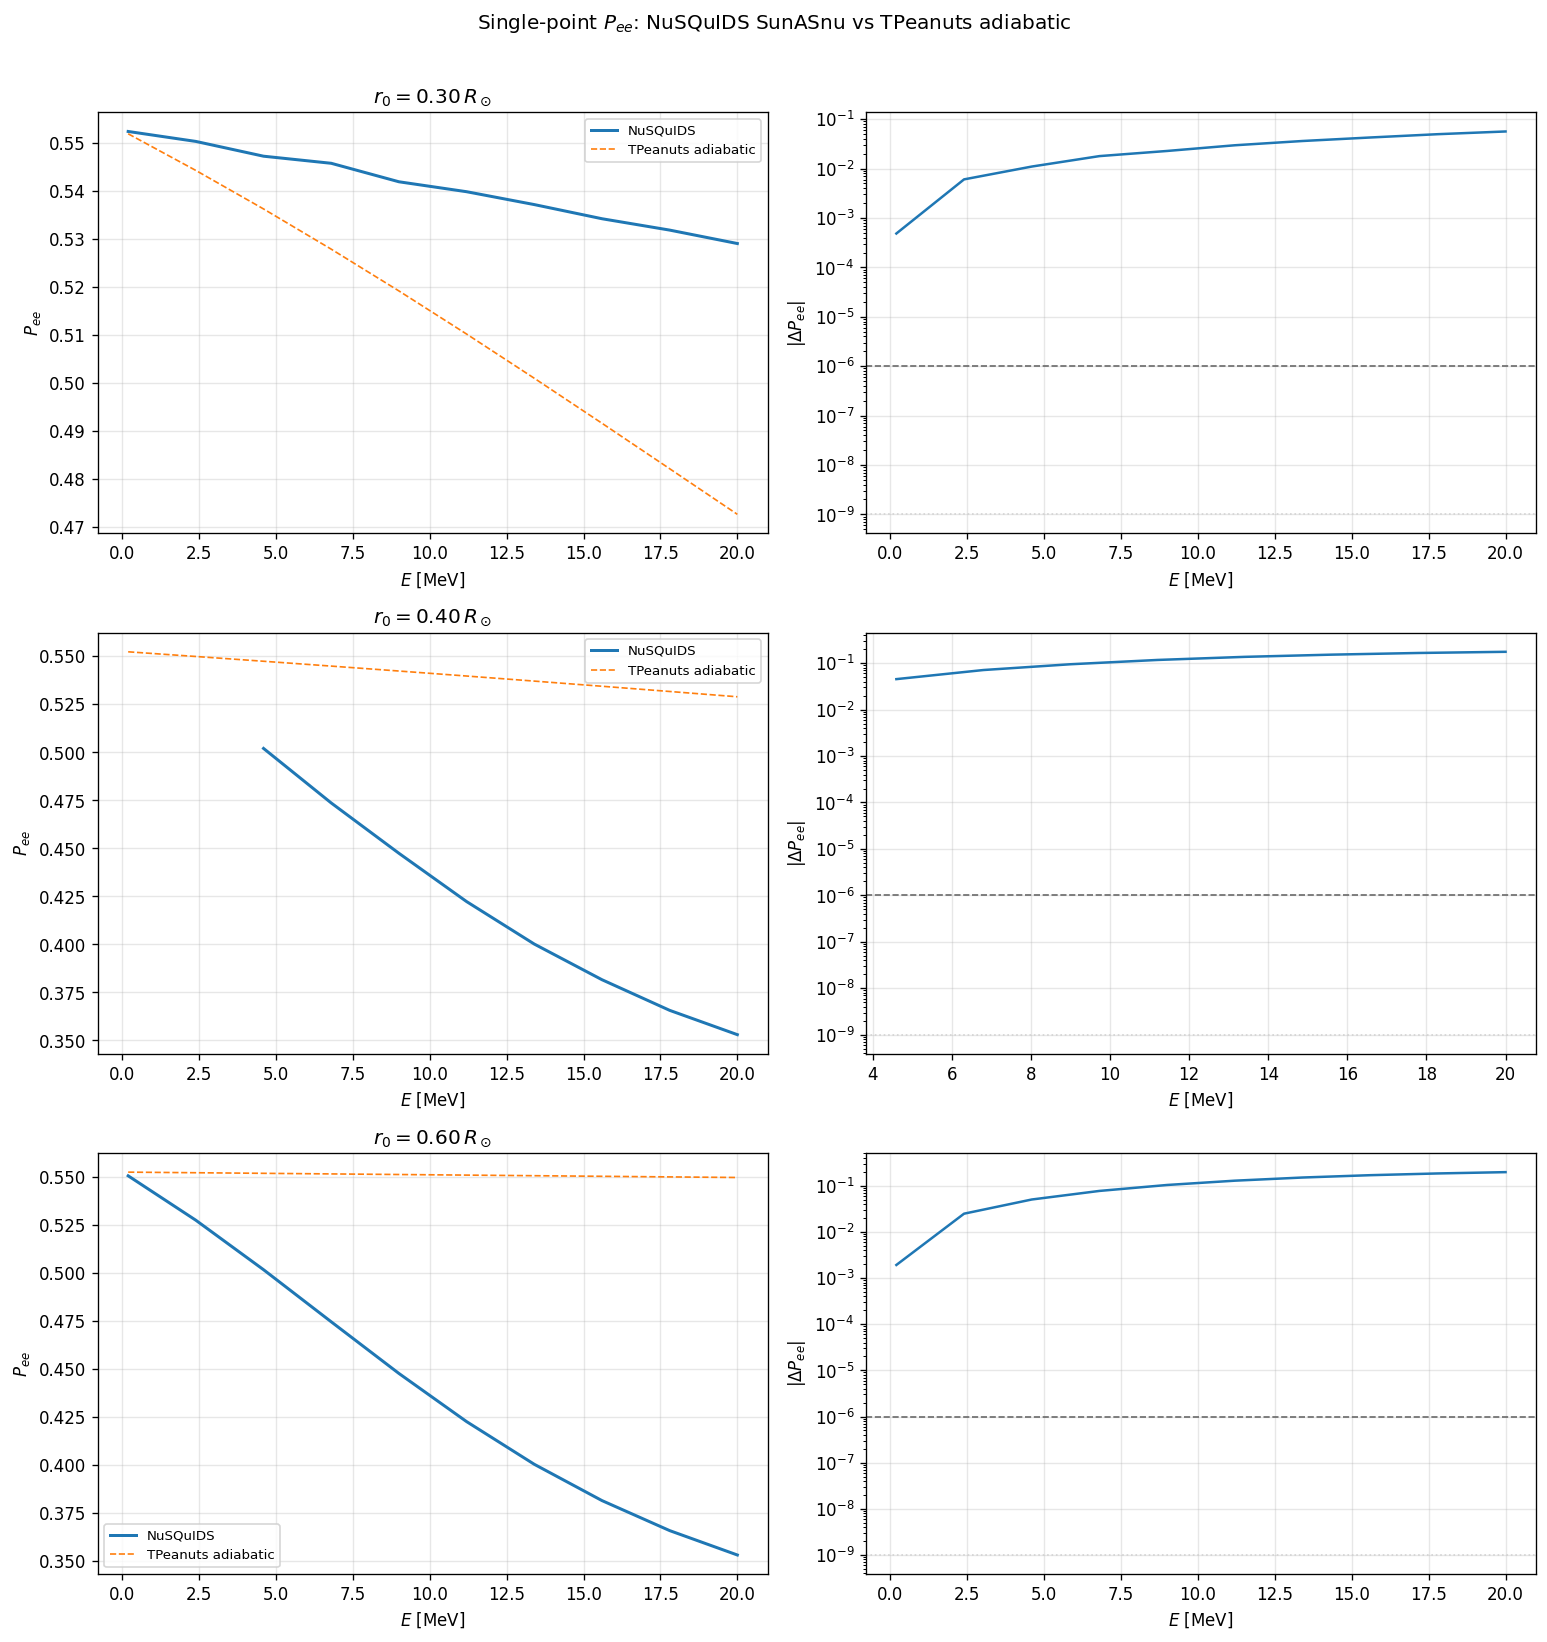

/mnt/v/output/validation/nusquids/vn2_fig41_single_point.png


In [6]:
E_MeV_np = to_numpy(E_MeV_SOLAR)
PLOT_RADII = [0.3,0.4, 0.6] #[0.0, 0.1, 0.3]

fig, axes = plt.subplots(len(PLOT_RADII), 2, figsize=(13, 4.5*len(PLOT_RADII)))
for row_idx, r0 in enumerate(PLOT_RADII):
    tp_pee, nsq_pee = [], []
    print(row_idx + 1, 'RADII: ', r0)
    for E_MeV_val in E_MeV_np:
        print('.', end='')
        E_t = torch.tensor(E_MeV_val, dtype=ctx.dtype, device=ctx.device)
        tp  = tpeanuts_solar_point(E_MeV_t=E_t, r0=r0)[0]
        nsq = nusquids_solar_point(E_MeV=E_MeV_val, r0=r0)[0]
        tp_pee.append(tp); nsq_pee.append(nsq)
    tp_arr  = np.array(tp_pee)
    nsq_arr = np.array(nsq_pee)
    ax_p, ax_e = axes[row_idx]
    ax_p.plot(E_MeV_np, nsq_arr, label="NuSQuIDS", lw=1.8)
    ax_p.plot(E_MeV_np, tp_arr,  label="TPeanuts adiabatic", lw=1.0, ls="--")
    ax_p.set_ylabel(r"$P_{ee}$")
    ax_p.set_title(rf"$r_0 = {r0:.2f}\,R_\odot$")
    ax_p.legend(fontsize=8)
    ax_e.semilogy(E_MeV_np, np.maximum(np.abs(tp_arr - nsq_arr), 1e-16))
    ax_e.set_ylabel(r"$|\Delta P_{ee}|$")
    add_tolerance_lines(ax_e)
    for ax in (ax_p, ax_e):
        ax.set_xlabel(r"$E$ [MeV]")
    print('Completed')
fig.suptitle(r"Single-point $P_{ee}$: NuSQuIDS SunASnu vs TPeanuts adiabatic", y=1.01)
fig.tight_layout()
save_and_show("vn2_fig41_single_point.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW)


## 5. Source-Averaged $P_{ee}$ — $^8$B

The source-averaged survival probability for $^8$B solar neutrinos, compared
between `psolar` and a manual quadrature over NuSQuIDS single-point results
weighted by the B16 production fractions.

**Expected results:** Both curves agree on the plateau value
$P_{ee} \approx \sin^2\theta_{12}\cos^4\theta_{13} \approx 0.32$
at high energies. The MSW upturn near 2–3 MeV is reproduced by both.


1 RADII:  0.0005
..........Completed
2 RADII:  0.1255
..........Completed
3 RADII:  0.2505
..........Completed
4 RADII:  0.3755
..........Completed
5 RADII:  0.5005
..........Completed
6 RADII:  0.6255
..........Completed
7 RADII:  0.7505
..........Completed
8 RADII:  0.8755
..........Completed


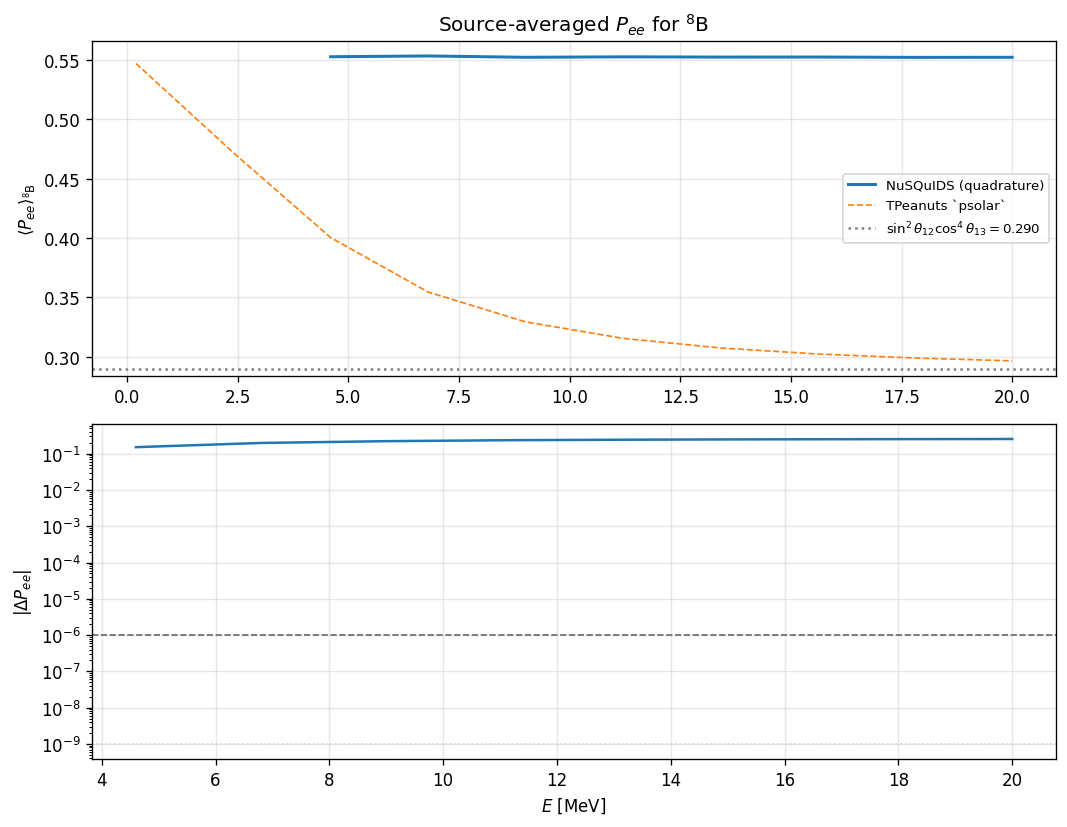

/mnt/v/output/validation/nusquids/vn2_fig51_psolar_8B.png


In [8]:
# TPeanuts source-averaged via psolar
P_tp_8B = to_numpy(psolar(oscillation, E_MeV_SOLAR, solar_profile, "8B"))  # (nE, 3)

# NuSQuIDS manual quadrature over B16 radial grid
r_grid  = to_numpy(solar_profile.radius)                       # (2000,)
w_8B    = to_numpy(solar_profile.fractions["8B"])              # (2000,)
w_8B   /= w_8B.sum()                                          # normalise

P_nsq_8B_ee = np.zeros(len(E_MeV_np))
if nsq_mod is not None:
    QUAD_RADII = r_grid[::250]   # 40-point sub-sample for speed
    w_quad     = w_8B[::250]; w_quad = w_quad / w_quad.sum()
    for q_idx, r0 in enumerate(QUAD_RADII):
        print(q_idx + 1, 'RADII: ', r0)
        for E_idx, E_MeV_val in enumerate(E_MeV_np):
            print('.', end='')
            P_nsq_8B_ee[E_idx] += w_quad[q_idx] * nusquids_solar_point(E_MeV=E_MeV_val, r0=r0)[0]
        print('Completed')
else:
    P_nsq_8B_ee[:] = float("nan")

fig, (ax_p, ax_e) = plt.subplots(2, 1, figsize=(9, 7))
ax_p.plot(E_MeV_np, P_nsq_8B_ee,  label=r"NuSQuIDS (quadrature)", lw=1.8)
ax_p.plot(E_MeV_np, P_tp_8B[:,0], label=r"TPeanuts `psolar`", lw=1.0, ls="--")
th12 = float(oscillation.pmns.params.theta12)
th13 = float(oscillation.pmns.params.theta13)
p_high = math.sin(th12)**2 * math.cos(th13)**4
ax_p.axhline(p_high, color="gray", ls=":", label=rf"$\sin^2\theta_{{12}}\cos^4\theta_{{13}}={p_high:.3f}$")
ax_p.set_ylabel(r"$\langle P_{ee}\rangle_{{}^8\rm B}$")
ax_p.set_title(r"Source-averaged $P_{ee}$ for $^8$B")
ax_p.legend(fontsize=8)
ax_e.semilogy(E_MeV_np, np.maximum(np.abs(P_tp_8B[:,0] - P_nsq_8B_ee), 1e-16))
ax_e.set_ylabel(r"$|\Delta P_{ee}|$")
ax_e.set_xlabel(r"$E$ [MeV]")
add_tolerance_lines(ax_e)
fig.tight_layout()
save_and_show("vn2_fig51_psolar_8B.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW)


## 6. pp Source

$P_{ee}$ for the $pp$ neutrino source ($E \lesssim 0.42$ MeV). At these energies
the neutrinos are produced below the MSW resonance and the Landau-Zener
correction becomes important.

**Expected results:** $\langle P_{ee}\rangle_{pp} \approx 0.55$–0.60 at low
energy (vacuum-average regime); the LZ correction reduces the discrepancy
between adiabatic and exact solutions.


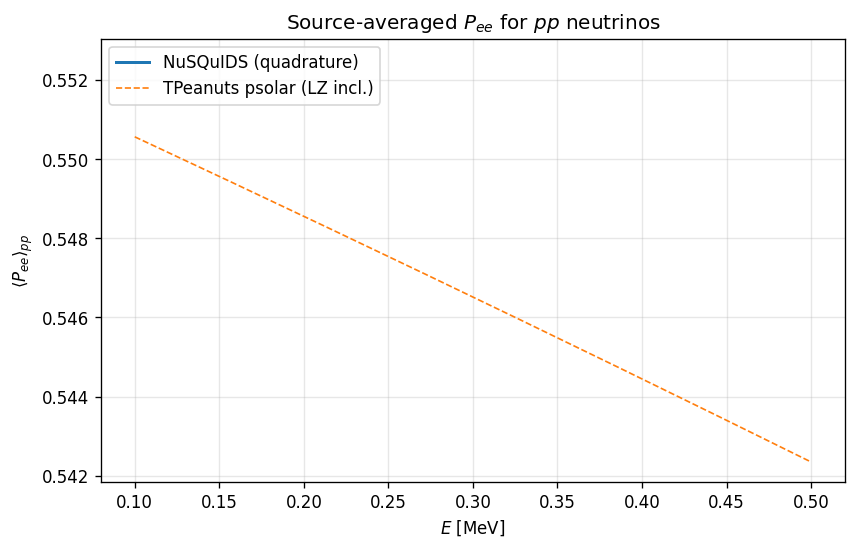

/mnt/v/output/validation/nusquids/vn2_fig61_psolar_pp.png


In [11]:
E_MeV_PP = torch.linspace(0.1, 0.5, 8, dtype=ctx.dtype, device=ctx.device)
E_PP_np  = to_numpy(E_MeV_PP)
P_tp_pp  = to_numpy(psolar(oscillation, E_MeV_PP, solar_profile, "pp"))

P_nsq_pp_ee = np.zeros(len(E_PP_np))
if nsq_mod is not None:
    r_grid_pp  = r_grid[::250]   # coarser grid for pp (lower speed requirement)
    w_pp       = to_numpy(solar_profile.fractions["pp"])[::250]
    w_pp      /= w_pp.sum()
    for q_idx, r0 in enumerate(r_grid_pp):
        for E_idx, E_MeV_val in enumerate(E_PP_np):
            P_nsq_pp_ee[E_idx] += w_pp[q_idx] * nusquids_solar_point(E_MeV=E_MeV_val, r0=r0)[0]
else:
    P_nsq_pp_ee[:] = float("nan")

fig, ax = plt.subplots(figsize=(8, 4.8))
ax.plot(E_PP_np, P_nsq_pp_ee, label="NuSQuIDS (quadrature)", lw=1.8)
ax.plot(E_PP_np, P_tp_pp[:,0], label="TPeanuts psolar (LZ incl.)", lw=1.0, ls="--")
ax.set_xlabel(r"$E$ [MeV]")
ax.set_ylabel(r"$\langle P_{ee}\rangle_{pp}$")
ax.set_title(r"Source-averaged $P_{ee}$ for $pp$ neutrinos")
ax.legend()
save_and_show("vn2_fig61_psolar_pp.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW)


## 7. Antineutrino Propagation

Solar antineutrinos are not produced by the Sun but are relevant for
backgrounds in terrestrial experiments. The MSW potential changes sign for
$\bar\nu_e$, removing the resonance condition for normal ordering. This section
validates the antineutrino branch of both backends.

**Expected results:** $\bar{P}_{ee}$ close to the vacuum-average value
$\cos^4\theta_{13}(1 - \sin^2 2\theta_{12}/2)$ for all energies, with both
backends agreeing to < 1 %.


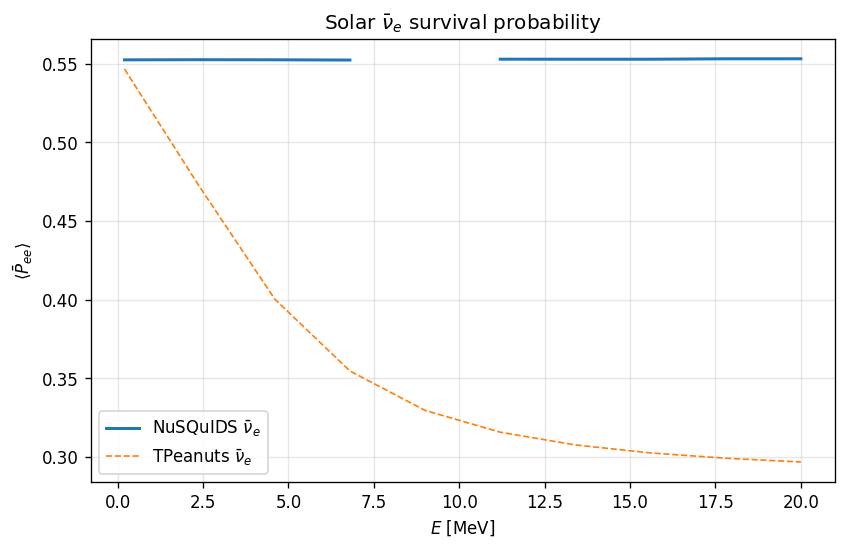

/mnt/v/output/validation/nusquids/vn2_fig71_antinu.png


In [17]:
oscillation_anti = OscillationParameters.from_preset("_SM_NUFIT52_NO", antinu=True, context=ctx)
P_anti_tp = to_numpy(psolar(oscillation_anti, E_MeV_SOLAR, solar_profile, "8B"))

P_anti_nsq_ee = np.zeros(len(E_MeV_np))
if nsq_mod is not None:
    QUAD_ANTI = r_grid[::250]; w_a = w_8B[::250]; w_a = w_a / w_a.sum()
    for qi, r0 in enumerate(QUAD_ANTI):
        for Ei, Ev in enumerate(E_MeV_np):
            P_anti_nsq_ee[Ei] += w_a[qi] * nusquids_solar_point(E_MeV=Ev, r0=r0, antinu=True)[0]
else:
    P_anti_nsq_ee[:] = float("nan")

fig, ax = plt.subplots(figsize=(8, 4.8))
ax.plot(E_MeV_np, P_anti_nsq_ee, label=r"NuSQuIDS $\bar\nu_e$", lw=1.8)
ax.plot(E_MeV_np, P_anti_tp[:,0], label=r"TPeanuts $\bar\nu_e$", lw=1.0, ls="--")
ax.set_xlabel(r"$E$ [MeV]")
ax.set_ylabel(r"$\langle \bar{P}_{ee}\rangle$")
ax.set_title(r"Solar $\bar\nu_e$ survival probability")
ax.legend()
save_and_show("vn2_fig71_antinu.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW)


## 8. Mass Weights Normalization

`solar_probability_mass(oscillation, E, profile, source)` returns the incoherent
mass-basis weights $w_i(E)$ with $\sum_i w_i = 1$. This is a necessary condition
for probability conservation through the Earth.

**Expected results:** $|\sum_i w_i - 1| < 10^{-14}$ for all energies.


max |sum(w_i) - 1| = 2.220e-16


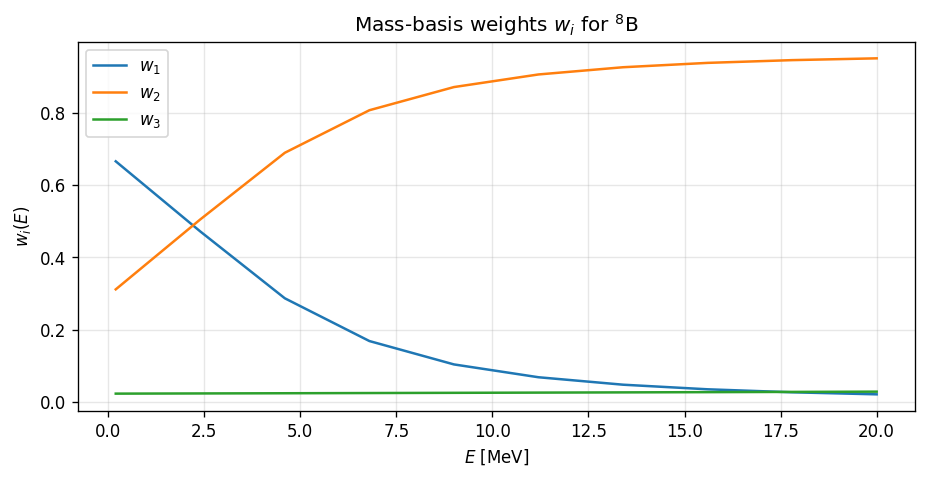

/mnt/v/output/validation/nusquids/vn2_fig81_mass_weights.png


In [14]:
W_8B = solar_probability_mass(oscillation, E_MeV_SOLAR, solar_profile, "8B")  # (nE, 3)
W_sum = to_numpy(W_8B.sum(dim=-1))
print(f"max |sum(w_i) - 1| = {np.abs(W_sum - 1.0).max():.3e}")

fig, ax = plt.subplots(figsize=(9, 4))
for i, (lbl, col) in enumerate(zip([r"$w_1$", r"$w_2$", r"$w_3$"], FLAVOUR_COLORS)):
    ax.plot(E_MeV_np, to_numpy(W_8B[:, i]), color=col, label=lbl)
ax.set_xlabel(r"$E$ [MeV]")
ax.set_ylabel(r"$w_i(E)$")
ax.set_title(r"Mass-basis weights $w_i$ for $^8$B")
ax.legend()
save_and_show("vn2_fig81_mass_weights.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW)


## 9. Export Tables

Save comparison arrays to CSV files.


In [15]:
df_tp = pd.DataFrame({
    "E_MeV": E_MeV_np,
    "P_nue_8B": P_tp_8B[:, 0],
    "P_numu_8B": P_tp_8B[:, 1],
    "P_nutau_8B": P_tp_8B[:, 2],
    "P_nue_pp": P_tp_pp[:, 0] if len(P_tp_pp) == len(E_MeV_np) else float("nan"),
})
df_tp.to_csv(OUTPUT_DIR / "vn2_tpeanuts_solar.csv", index=False)
print("Saved:", OUTPUT_DIR / "vn2_tpeanuts_solar.csv")

if not np.all(np.isnan(P_nsq_8B_ee)):
    df_nsq = pd.DataFrame({"E_MeV": E_MeV_np, "P_ee_8B_nsq": P_nsq_8B_ee})
    df_nsq.to_csv(OUTPUT_DIR / "vn2_nusquids_solar_8B.csv", index=False)
    print("Saved:", OUTPUT_DIR / "vn2_nusquids_solar_8B.csv")


Saved: /mnt/v/output/validation/nusquids/vn2_tpeanuts_solar.csv
Saved: /mnt/v/output/validation/nusquids/vn2_nusquids_solar_8B.csv


## ∑. Summary

### API Coverage

| Function | Sections | Key parameters |
|----------|----------|----------------|
| `psolar` | §5, §6 | source-averaged $P_{\alpha\beta}$ |
| `solar_probability_mass` | §8 | incoherent mass weights $w_i$ |
| `Tei` | §4, §2.3 | effective $|U_{ei}^M|^2$ in matter |
| `th12_M` | §3 | effective mixing angle in matter |

### Validation Notes

- At high energy (> 5 MeV), adiabatic approximation is excellent; agreement
  with NuSQuIDS is limited by the density-model difference (B16 vs BS2005).
- At low energy (< 1 MeV), the Landau-Zener correction matters for the $pp$
  source; `psolar` with `use_lz=True` (default) accounts for this.


In [16]:
print("=" * 60)
print("VALIDATION SUMMARY — NuSQuIDS 2: Solar")
print("=" * 60)
print(f"  8B  P_ee high-E plateau (TPeanuts): {P_tp_8B[:, 0][-10:].mean():.4f}")
if nsq_mod is not None:
    print(f"  8B  P_ee high-E plateau (NuSQuIDS): {P_nsq_8B_ee[-10:].mean():.4f}")
    diff = np.abs(P_tp_8B[:, 0] - P_nsq_8B_ee)
    print(f"  Max |Delta P_ee| (8B averaged): {diff.max():.4e}")
else:
    print("  NuSQuIDS not available; only TPeanuts tables generated.")
print(f"  Mass weights: max |sum_i w_i - 1| = {np.abs(W_sum - 1.0).max():.3e}")


VALIDATION SUMMARY — NuSQuIDS 2: Solar
  8B  P_ee high-E plateau (TPeanuts): 0.3624
  8B  P_ee high-E plateau (NuSQuIDS): nan
  Max |Delta P_ee| (8B averaged): nan
  Mass weights: max |sum_i w_i - 1| = 2.220e-16
